In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [8]:
df=pd.read_csv("OneDrive/Desktop/dbms_test/heart (1).csv")
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [9]:
df=df.drop_duplicates()
print('Shape after removing duplicates:',df.shape)

print(df.isna().sum())

df.fillna(df.mean(),inplace=True)

Shape after removing duplicates: (302, 14)
age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


In [10]:
subset1=df[['age','cp','trtbps','chol']]
subset2=df[['exng','slp','output']]

merged = pd.concat((subset1,subset2),axis=1)
merged.head()


,age,cp,trtbps,chol,exng,slp,output
0,63,3,145,233,0,0,1
1,37,2,130,250,0,0,1
2,41,1,130,204,0,2,1
3,56,1,120,236,0,2,1
4,57,0,120,354,1,2,1


In [14]:
# splitting data using train test split
x = df[['cp','thalachh','exng','oldpeak','slp','caa']]
y = df.output
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((241, 6), (61, 6), (241,), (61,))

In [15]:
scaler=StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [16]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    return column[~outlier_mask]
    
# Remove outliers for each column using a loop
col_name = ['cp','thalachh','exng','oldpeak','slp','caa']
for col in col_name:
    df[col] = remove_outliers(df[col])

In [17]:
target = 'output' # Assuming 'output' is the target column based on previous code

# Fill NaN values introduced by outlier removal before splitting the data
df.fillna(df.mean(), inplace=True)

X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) # Added random_state for reproducibility

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000) # Increased max_iter to help convergence
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8524590163934426


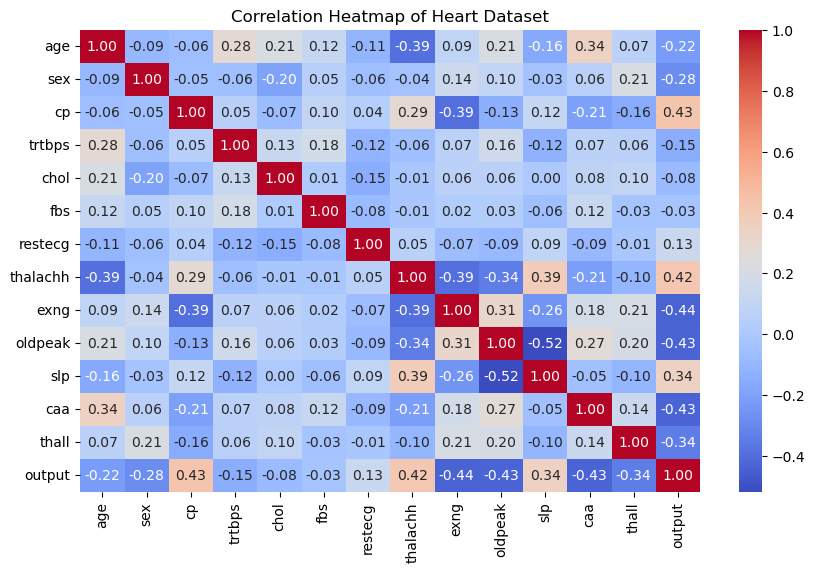

In [18]:
#heat map
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap of Heart Dataset")
#plt.tight_layout()
plt.show()


<Axes: xlabel='age', ylabel='cp'>

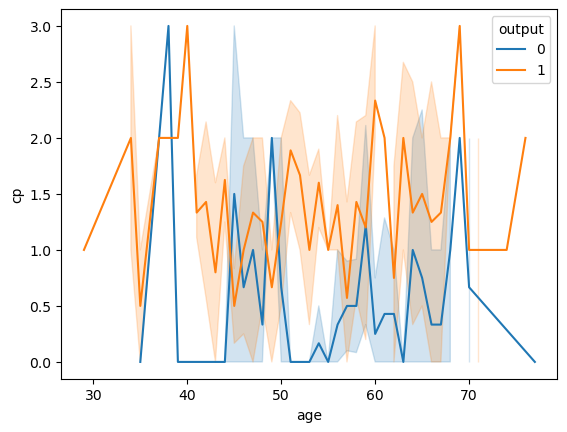

In [20]:
sns.lineplot(data=df,x=df.age,y=df.cp,hue='output')


<Axes: xlabel='age', ylabel='trtbps'>

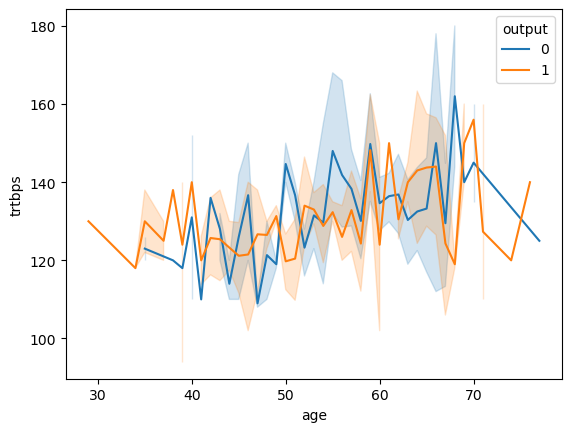

In [21]:
sns.lineplot(data=df,x=df.age,y=df.trtbps,hue='output')


<Axes: xlabel='age', ylabel='chol'>

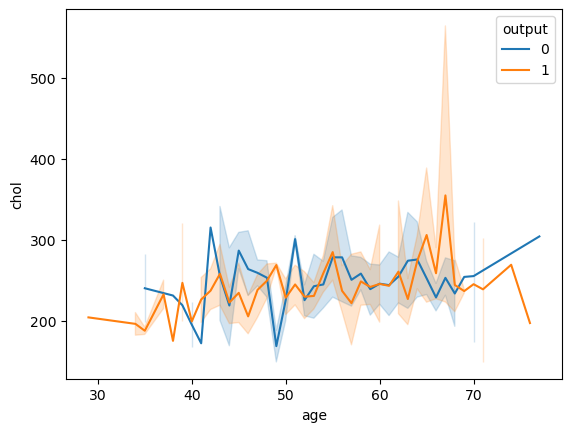

In [22]:
sns.lineplot(data=df,x=df.age,y=df.chol,hue='output')


<Axes: xlabel='oldpeak', ylabel='exng'>

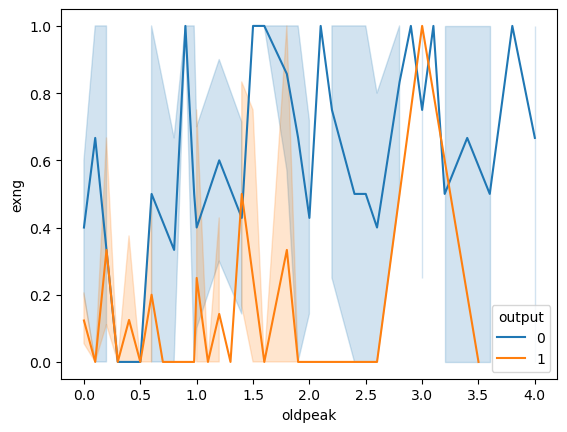

In [23]:
sns.lineplot(df,x=df.oldpeak,y=df.exng,hue='output')

<Axes: xlabel='output', ylabel='Count'>

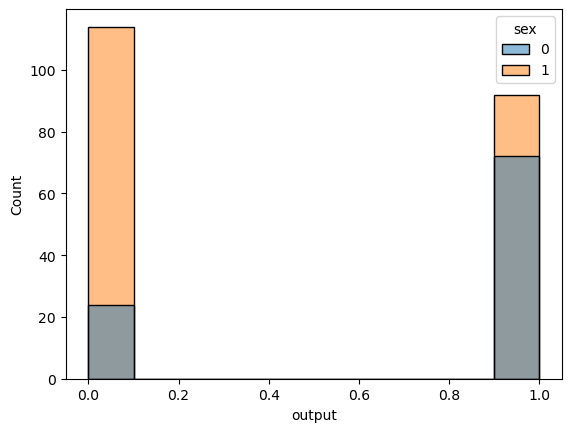

In [27]:
# Shows the Distribution of Heat Diseases with respect to male and female
sns.histplot(data=df, x=df.output, hue=df.sex)

<Axes: xlabel='cp', ylabel='Count'>

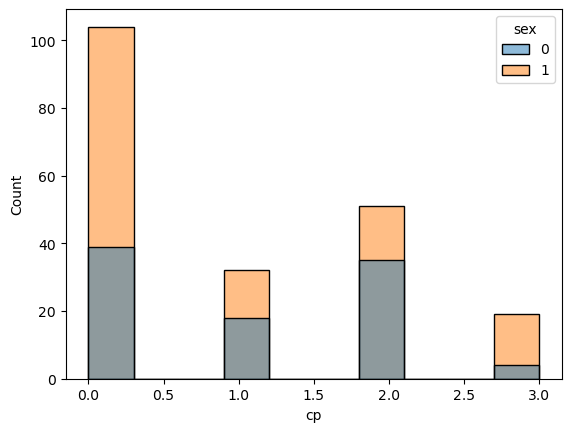

In [25]:
sns.histplot(data=df, x=df.cp, hue=df.sex)

<Axes: xlabel='age', ylabel='Count'>

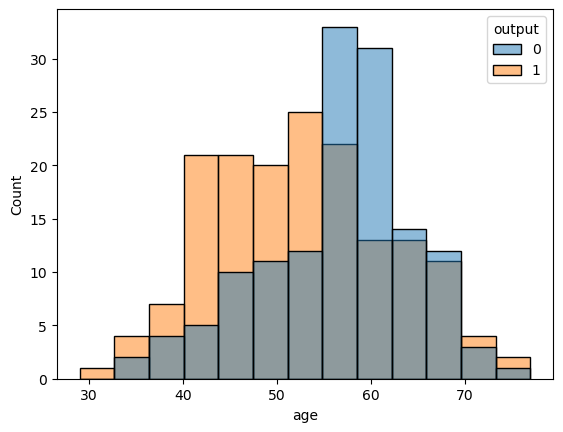

In [26]:
# Shows the Distribution of age w.r.t output
sns.histplot(data=df,x=df['age'], hue='output')